In [2]:
import sys, os
sys.path.insert(0, '../../')
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt 
from gasp import load_dataset

import logging
logging.getLogger('gasp.dataset').setLevel(logging.DEBUG)
logging.basicConfig() 

In [3]:
ds = {
    'path':'2025_10_1_sphere_phantom',
}

M = load_dataset(**ds, filter='_fa60_')
print('shape: ', M.shape)

DEBUG:gasp.dataset:Filter: _fa60_
DEBUG:gasp.dataset:Loading from: /Users/michael/projects/mri/GASP/notebooks/datasets/../../gasp/../data/2025_10_1_sphere_phantom
DEBUG:gasp.dataset:Files: ['meas_MID231_bSSFP_gasp_knee_fa60_TR7ms_FID84860.dat', 'meas_MID232_bSSFP_gasp_knee_fa60_TR14ms_FID84861.dat', 'meas_MID233_bSSFP_gasp_knee_fa60_TR28ms_FID84862.dat']


pymapVBVD version 0.6.1
Software version: VB


pymapVBVD version 0.6.1
Software version: VB


pymapVBVD version 0.6.1
Software version: VB


shape:  (256, 256, 8, 16, 3)


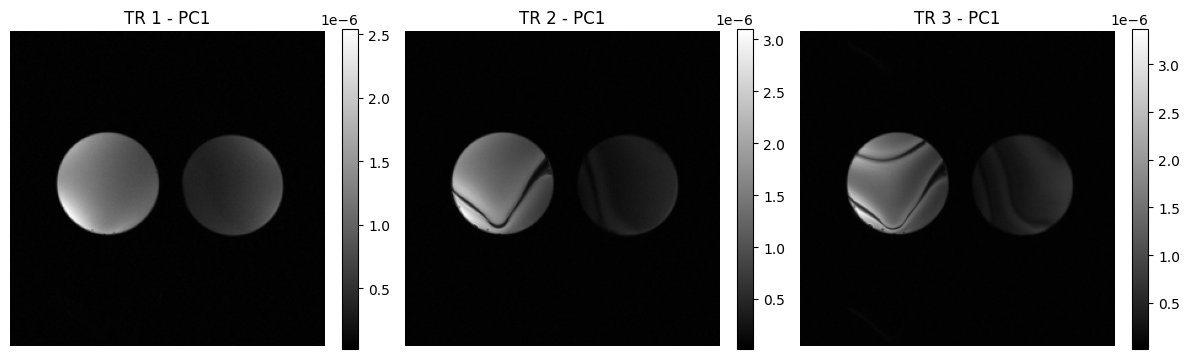

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# M shape: (Height, Width, Coil, PCs, TRs)
# Combine coils using root sum of squares (optimal for magnitude)
M_rss = np.sqrt(np.sum(np.abs(M)**2, axis=2))  # shape: (H, W, PCs, TRs)

# Extract first PC (index 0) for all 3 TRs
first_pc = M_rss[:, :, 0, :]  # shape: (H, W, TRs)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    im = axes[i].imshow(np.abs(first_pc[:, :, i]), cmap='gray')
    axes[i].set_title(f'TR {i+1} - PC1')
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046)
plt.tight_layout()
plt.show()